In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "font.family":       "serif",
    "font.size":         11,
    "axes.titlesize":    12,
    "axes.labelsize":    11,
    "figure.dpi":        150,
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

SEED         = 42
PARQUET_PATH = r"C:\Users\super\Desktop\Data Thesis\final_df_clustered.parquet"

np.random.seed(SEED)

print("Loading data...")
final_df = pd.read_parquet(PARQUET_PATH)

gaze_cols = [c for c in final_df.columns if "gaze" in c]
pose_cols = [c for c in final_df.columns if "pose" in c]
au_r_cols = [c for c in final_df.columns if c.startswith("AU") and c.endswith("_r")]
au_c_cols = [c for c in final_df.columns if c.startswith("AU") and c.endswith("_c")]
FEATURE_COLS = au_r_cols + au_c_cols + gaze_cols + pose_cols
N_FEATURES   = len(FEATURE_COLS)

print(f"  Features: {N_FEATURES}  |  Participants: {final_df['participant_id'].nunique()}")

Loading data...
  Features: 49  |  Participants: 102


In [2]:
clip_meta = (
    final_df.groupby("clip_id")
    .agg(
        engagement         = ("engagement",         "first"),
        participant_id     = ("participant_id",     "first"),
        behavioral_cluster = ("behavioral_cluster", "first")
    )
    .reset_index()
)

scaler = StandardScaler()
final_df[FEATURE_COLS] = scaler.fit_transform(final_df[FEATURE_COLS])

print(f"Total clips: {len(clip_meta):,}")
print(f"Cluster counts:\n{clip_meta['behavioral_cluster'].value_counts()}")

Total clips: 12,093
Cluster counts:
behavioral_cluster
1    8581
0    3512
Name: count, dtype: int64


In [3]:
def clip_level_features(clips_df, full_df):
    relevant = full_df[full_df["clip_id"].isin(clips_df["clip_id"])]
    clip_means = relevant.groupby("clip_id")[FEATURE_COLS].mean()
    merged = clips_df.merge(clip_means, on="clip_id", how="left")
    return merged

all_clip_features = clip_level_features(clip_meta, final_df)

centroid_distances = []
for cluster in [0, 1]:
    cluster_df = all_clip_features[all_clip_features["behavioral_cluster"] == cluster]
    engaged_df    = cluster_df[cluster_df["engagement"] == 1]
    disengaged_df = cluster_df[cluster_df["engagement"] == 0]

    engaged_centroid    = engaged_df[FEATURE_COLS].mean().values
    disengaged_centroid = disengaged_df[FEATURE_COLS].mean().values

    euclidean_dist = np.linalg.norm(engaged_centroid - disengaged_centroid)

    centroid_distances.append({
        "cluster": cluster,
        "n_engaged": len(engaged_df),
        "n_disengaged": len(disengaged_df),
        "centroid_distance": euclidean_dist
    })

centroid_df = pd.DataFrame(centroid_distances)
print("Engaged vs disengaged centroid distance per cluster (z-scored feature space):")
print(centroid_df.to_string(index=False))
print("\nSmaller distance = engaged/disengaged clips look MORE similar")
print("(more 'ambiguous') in feature space within that cluster.")

Engaged vs disengaged centroid distance per cluster (z-scored feature space):
 cluster  n_engaged  n_disengaged  centroid_distance
       0       2717           795           1.682789
       1       6993          1588           1.063625

Smaller distance = engaged/disengaged clips look MORE similar
(more 'ambiguous') in feature space within that cluster.


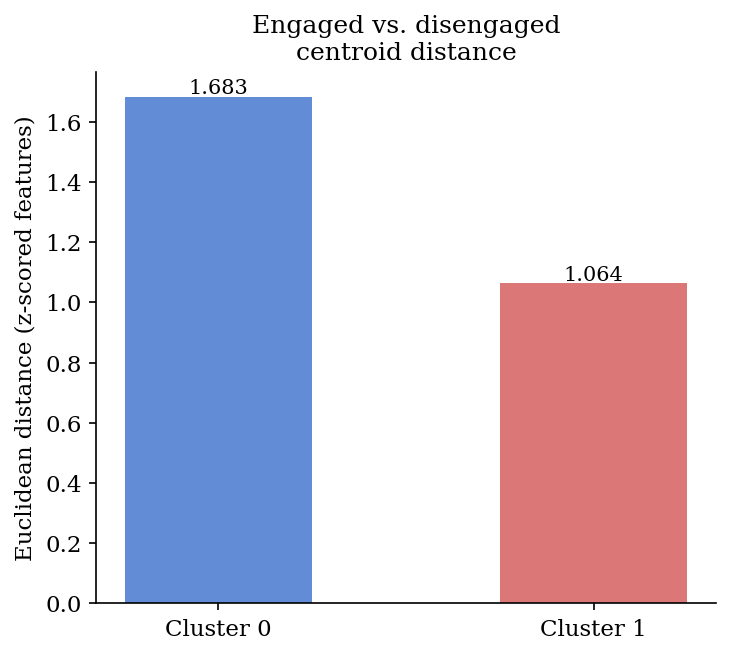

Saved: fig_centroid_distance.pdf/.png


In [5]:
fig, ax = plt.subplots(figsize=(5, 4.5))

colors = ["#4878CF", "#D65F5F"]
bars = ax.bar(
    centroid_df["cluster"].astype(str),
    centroid_df["centroid_distance"],
    color=colors,
    alpha=0.85,
    width=0.5
)

ax.set_xticks(range(len(centroid_df)))
ax.set_xticklabels([f"Cluster {c}" for c in centroid_df["cluster"]])

ax.set_ylabel("Euclidean distance (z-scored features)")
ax.set_title("Engaged vs. disengaged\ncentroid distance")

for bar, val in zip(bars, centroid_df["centroid_distance"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.01,
        f"{val:.3f}",
        ha="center",
        fontsize=10
    )

plt.tight_layout()
#plt.savefig("fig_centroid_distance.pdf", bbox_inches="tight")
#plt.savefig("fig_centroid_distance.png", bbox_inches="tight")
plt.show()

print("Saved: fig_centroid_distance.pdf/.png")